In [1]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib import rc

rc('lines', lw=2, c='r')
rc('font', size=14)

_dtype_f = np.float32

In [2]:
#Parameters
Tmin = 800
Tmax = 1200
dT = 1


T = np.arange(Tmin, Tmax, dT, dtype = _dtype_f)

#Parameters
Td = 978.4
DrH = dict(CtCO = -110.5, 
          COtCO2 = -282.8,
          CtCO2 = -393.3/2)
DrS = dict(CtCO = 89.5*10**(-3), 
          COtCO2 = -86.6*10**(-3),
          CtCO2 = 2.9*10**(-3)/2)

up = dict(CtCO = True, 
          COtCO2 = True,
          CtCO2 = False) 

colors = dict(zip(tuple(DrH.keys()), ('blue', 'green', 'red')))

filt_d = T < Td
filt_u = T > Td

In [3]:
DrG = lambda T, DrH, DrS : DrH - T * DrS

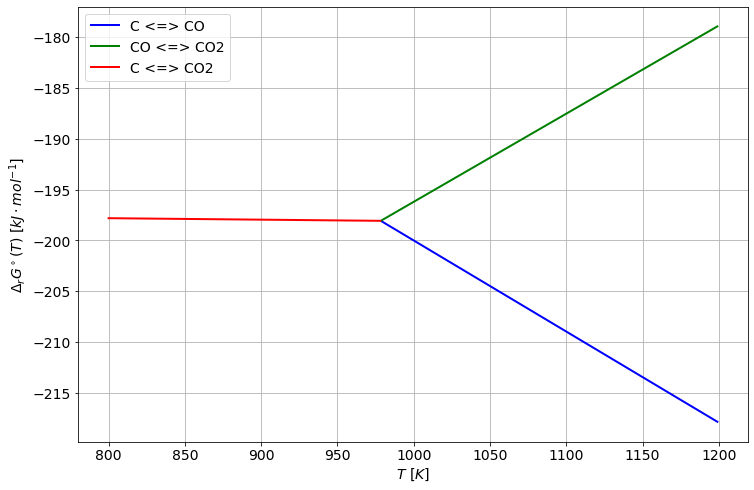

In [5]:
fig = plt.figure(figsize = (12,8))
ax = fig.subplots()

for key in DrH.keys() : 
    if up[key] : 
        ax.plot(T[filt_u], DrG(T[filt_u],DrH[key],DrS[key]), 
            label = key.replace("t", " <=> "), color = colors[key])
    else : 
        ax.plot(T[filt_d], DrG(T[filt_d],DrH[key],DrS[key]), 
            label = key.replace("t", " <=> "), color = colors[key])

#ax.plot(T, DrG(T, DrH["COtCO2"] - DrH["CtCO"], DrS["COtCO2"] - DrS["CtCO"]) , color = 'gray')


ax.set_xlabel("$T$ [$K$]")
ax.set_ylabel("$\Delta_r G^\circ (T)$ [$kJ \cdot mol^{-1}$]")
ax.legend()

ax.grid()

#fig.savefig